In [3]:
from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier

In [4]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("fraud-detection")

mlflow.xgboost.autolog()

In [5]:
def load_and_combine_pkl(data_dir='../data', pattern='*.pkl', 
                          add_date_column=False, verbose=True):
    """
    Load and combine all .pkl files in a folder into a single DataFrame
    
    Parameters:
    -----------
    data_dir : str
        Path to the folder containing files
    pattern : str
        Pattern of files to load (default: '*.pkl')
    add_date_column : bool
        Whether to add a 'file_date' column tracking the source file
    verbose : bool
        Print progress while loading
    
    Returns:
    --------
    pd.DataFrame
        Combined DataFrame from all files
    """
    data_path = Path(data_dir)
    
    # Find all files and sort by name (automatically sorts by date)
    pkl_files = sorted(data_path.glob(pattern))
    
    if len(pkl_files) == 0:
        raise FileNotFoundError(f"No files found with pattern '{pattern}' in {data_dir}")
    
    if verbose:
        print(f"Found {len(pkl_files)} files")
    
    # Load each file and store in list
    dfs = []
    for file_path in pkl_files:
        if verbose:
            print(f"Loading {file_path.name}...", end=' ')
        
        try:
            df = pd.read_pickle(file_path)
            
            # Optional: add column tracking date
            if add_date_column:
                # Extract date from filename (2018-04-01.pkl -> 2018-04-01)
                file_date = file_path.stem
                df['file_date'] = file_date
            
            dfs.append(df)
            
            if verbose:
                print(f"Shape: {df.shape}")
                
        except Exception as e:
            print(f"Error: {e}")
            continue
    
    # Combine all DataFrames
    if verbose:
        print("\nCombining all DataFrames...")
    
    combined_df = pd.concat(dfs, ignore_index=True)
    
    if verbose:
        print(f"Final shape: {combined_df.shape}")
        print(f"Memory usage: {combined_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    return combined_df

In [7]:
data = load_and_combine_pkl(verbose=False)
print(data.head(5))

   TRANSACTION_ID         TX_DATETIME CUSTOMER_ID TERMINAL_ID  TX_AMOUNT  \
0               0 2018-04-01 00:00:31         596        3156      57.16   
1               1 2018-04-01 00:02:10        4961        3412      81.51   
2               2 2018-04-01 00:07:56           2        1365     146.00   
3               3 2018-04-01 00:09:29        4128        8737      64.49   
4               4 2018-04-01 00:10:34         927        9906      50.99   

  TX_TIME_SECONDS TX_TIME_DAYS  TX_FRAUD  TX_FRAUD_SCENARIO  
0              31            0         0                  0  
1             130            0         0                  0  
2             476            0         0                  0  
3             569            0         0                  0  
4             634            0         0                  0  


In [4]:
data.isnull().sum()

TRANSACTION_ID       0
TX_DATETIME          0
CUSTOMER_ID          0
TERMINAL_ID          0
TX_AMOUNT            0
TX_TIME_SECONDS      0
TX_TIME_DAYS         0
TX_FRAUD             0
TX_FRAUD_SCENARIO    0
dtype: int64

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754155 entries, 0 to 1754154
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   TRANSACTION_ID     int64         
 1   TX_DATETIME        datetime64[ns]
 2   CUSTOMER_ID        object        
 3   TERMINAL_ID        object        
 4   TX_AMOUNT          float64       
 5   TX_TIME_SECONDS    object        
 6   TX_TIME_DAYS       object        
 7   TX_FRAUD           int64         
 8   TX_FRAUD_SCENARIO  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 120.4+ MB


In [6]:
data.describe()

,TRANSACTION_ID,TX_DATETIME,TX_AMOUNT,TX_FRAUD,TX_FRAUD_SCENARIO
count,1.754155e+06,1754155,1.754155e+06,1.754155e+06,1.754155e+06
mean,8.770770e+05,2018-07-01 11:20:33.708572160,5.363230e+01,8.369272e-03,1.882388e-02
min,0.000000e+00,2018-04-01 00:00:31,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.385385e+05,2018-05-16 14:40:46.500000,2.101000e+01,0.000000e+00,0.000000e+00
50%,8.770770e+05,2018-07-01 11:11:10,4.464000e+01,0.000000e+00,0.000000e+00
75%,1.315616e+06,2018-08-16 08:01:01.500000,7.695000e+01,0.000000e+00,0.000000e+00
max,1.754154e+06,2018-09-30 23:59:57,2.628000e+03,1.000000e+00,3.000000e+00
std,5.063811e+05,NaN,4.232649e+01,9.110012e-02,2.113263e-01


In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
from ydata_profiling import ProfileReport

profile = ProfileReport(data, title="Fraud Detection EDA")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:06<00:00,  1.29it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
# Add simple calendar flags to capture weekend behavior and nighttime activity.
data['IS_WEEKEND'] = data['TX_DATETIME'].dt.dayofweek >= 5
data['IS_NIGHT'] = (data['TX_DATETIME'].dt.hour < 6) | (data['TX_DATETIME'].dt.hour >= 22)

In [9]:
# Sort by customer and time so every rolling statistic uses only earlier transactions.
data = data.sort_values(['CUSTOMER_ID', 'TX_DATETIME'])
# Set TX_DATETIME as the index because the rolling windows are defined in time units.
data = data.set_index('TX_DATETIME')

# Customer history features are built from past transactions only.
# closed='left' excludes the current transaction from each window to prevent leakage.
# The 1D, 7D, and 30D windows capture short-, medium-, and longer-term customer behavior.
data['CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_1D'] = data.groupby('CUSTOMER_ID')['TRANSACTION_ID'].rolling('1D', closed='left').count().reset_index(0, drop=True).fillna(0)
data['CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_7D'] = data.groupby('CUSTOMER_ID')['TRANSACTION_ID'].rolling('7D', closed='left').count().reset_index(0, drop=True).fillna(0)
data['CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_30D'] = data.groupby('CUSTOMER_ID')['TRANSACTION_ID'].rolling('30D', closed='left').count().reset_index(0, drop=True).fillna(0)
data['CUSTOMER_AVG_AMOUNT_WINDOW_1D'] = data.groupby('CUSTOMER_ID')['TX_AMOUNT'].rolling('1D', closed='left').mean().reset_index(0, drop=True).fillna(0)
data['CUSTOMER_AVG_AMOUNT_WINDOW_7D'] = data.groupby('CUSTOMER_ID')['TX_AMOUNT'].rolling('7D', closed='left').mean().reset_index(0, drop=True).fillna(0)
data['CUSTOMER_AVG_AMOUNT_WINDOW_30D'] = data.groupby('CUSTOMER_ID')['TX_AMOUNT'].rolling('30D', closed='left').mean().reset_index(0, drop=True).fillna(0)

# Restore TX_DATETIME as a regular column after feature creation.
data = data.reset_index()

data.head()

,TX_DATETIME,TRANSACTION_ID,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,IS_WEEKEND,IS_NIGHT,CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_1D,CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_7D,CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_30D,CUSTOMER_AVG_AMOUNT_WINDOW_1D,CUSTOMER_AVG_AMOUNT_WINDOW_7D,CUSTOMER_AVG_AMOUNT_WINDOW_30D
0,2018-04-01 07:19:05,1758,0,6076,123.59,26345,0,0,0,True,False,0.0,0.0,0.0,0.000000,0.000,0.000
1,2018-04-01 18:00:16,8275,0,858,77.34,64816,0,0,0,True,False,1.0,1.0,1.0,123.590000,123.590,123.590
2,2018-04-01 19:02:02,8640,0,6698,46.51,68522,0,0,0,True,False,2.0,2.0,2.0,100.465000,100.465,100.465
3,2018-04-02 08:51:06,12169,0,6569,54.72,118266,1,0,0,False,False,2.0,3.0,3.0,61.925000,82.480,82.480
4,2018-04-02 14:05:38,15764,0,7707,63.30,137138,1,0,0,False,False,3.0,4.0,4.0,59.523333,75.540,75.540


In [10]:
def get_count_risk_rolling_window(terminal_transactions, delay_period=7, windows_size_in_days=[1,7,30], feature="TERMINAL"):
    
    # Sort each terminal's transactions chronologically before computing rolling history.
    terminal_transactions = terminal_transactions.sort_values('TX_DATETIME')
    
    # Use the timestamp as the index so time-based rolling windows can be applied.
    terminal_transactions.index = terminal_transactions.TX_DATETIME
    
    # Start with a baseline delay window.
    # NB_FRAUD_DELAY = number of fraud transactions in the last delay_period days.
    # NB_TX_DELAY = total number of transactions in the last delay_period days.
    NB_FRAUD_DELAY = terminal_transactions['TX_FRAUD'].rolling(str(delay_period)+'d').sum()
    NB_TX_DELAY = terminal_transactions['TX_FRAUD'].rolling(str(delay_period)+'d').count()
    
    for window_size in windows_size_in_days:
    
        # Build a wider lookback window that reaches delay_period + window_size days into the past.
        # The subtraction below removes the most recent delay_period slice, leaving only
        # the historical segment used to compute the feature for this window size.
        NB_FRAUD_DELAY_WINDOW = terminal_transactions['TX_FRAUD'].rolling(str(delay_period+window_size)+'d').sum()
        NB_TX_DELAY_WINDOW = terminal_transactions['TX_FRAUD'].rolling(str(delay_period+window_size)+'d').count()
    
        # Fraud and transaction counts for the target historical window.
        NB_FRAUD_WINDOW = NB_FRAUD_DELAY_WINDOW - NB_FRAUD_DELAY
        NB_TX_WINDOW = NB_TX_DELAY_WINDOW - NB_TX_DELAY
    
        # Risk score = fraud count / transaction count in that historical window.
        # This produces:
        # - TERMINAL_NB_TX_1DAY_WINDOW, TERMINAL_NB_TX_7DAY_WINDOW, TERMINAL_NB_TX_30DAY_WINDOW
        # - TERMINAL_RISK_1DAY_WINDOW, TERMINAL_RISK_7DAY_WINDOW, TERMINAL_RISK_30DAY_WINDOW
        RISK_WINDOW = NB_FRAUD_WINDOW/NB_TX_WINDOW
        
        terminal_transactions[feature+'_NB_TX_'+str(window_size)+'DAY_WINDOW'] = list(NB_TX_WINDOW)
        terminal_transactions[feature+'_RISK_'+str(window_size)+'DAY_WINDOW'] = list(RISK_WINDOW)
        
    terminal_transactions.index = terminal_transactions.TRANSACTION_ID
    
    # Fill undefined risk scores with 0 when there are no transactions in the window.
    terminal_transactions.fillna(0,inplace=True)
    
    return terminal_transactions

# Build terminal-level rolling risk features and then restore chronological order.
data = data.groupby('TERMINAL_ID').apply(lambda x: get_count_risk_rolling_window(x, delay_period=7, windows_size_in_days=[1,7,30], feature="TERMINAL"))
data = data.sort_values('TX_DATETIME').reset_index(drop=True)

C:\Users\PC LENOVO\AppData\Local\Temp\ipykernel_30968\3751098665.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('TERMINAL_ID').apply(lambda x: get_count_risk_rolling_window(x, delay_period=7, windows_size_in_days=[1,7,30], feature="TERMINAL"))


In [11]:
from imblearn.pipeline import Pipeline

# Sort chronologically before creating the split and feature matrix.
date_sorted = data.sort_values('TX_DATETIME').reset_index(drop=True)
data.columns

# These features are grouped into customer behavior, terminal risk history, and calendar context.
# Terminal_RISK_* measures the fraud rate observed in older terminal activity windows.
# Terminal_NB_TX_* measures how many past transactions existed in those same windows.
# For each transaction, the 1D, 7D, and 30D versions are computed from past terminal history only,
# so they summarize very short, medium, and longer-term terminal behavior without leakage.
feature_cols = [
    'TX_AMOUNT',
    'CUSTOMER_AVG_AMOUNT_WINDOW_1D',
    'CUSTOMER_AVG_AMOUNT_WINDOW_7D',
    'CUSTOMER_AVG_AMOUNT_WINDOW_30D',
    'CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_1D',
    'CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_7D',
    'CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_30D',
    'TERMINAL_RISK_1DAY_WINDOW',
    'TERMINAL_RISK_7DAY_WINDOW',
    'TERMINAL_RISK_30DAY_WINDOW',
    'TERMINAL_NB_TX_1DAY_WINDOW',
    'TERMINAL_NB_TX_7DAY_WINDOW',
    'TERMINAL_NB_TX_30DAY_WINDOW',
    'IS_WEEKEND',
    'IS_NIGHT'
]

X = date_sorted[feature_cols]
y = date_sorted['TX_FRAUD']


fraud_count = y.sum()
normal_count = len(y) - fraud_count
scale_pos_weight = 1

# Keep the newest 15% of records as the hold-out test set so time order stays intact.
test_size = int(0.15 * len(X))
X_train_valid = X.iloc[:-test_size]
X_test_final = X.iloc[-test_size:]
y_train_valid = y.iloc[:-test_size]
y_test_final = y.iloc[-test_size:]

print(f"Train+Valid size: {len(X_train_valid):,} ({len(X_train_valid)/len(X)*100:.1f}%)")
print(f"Test size: {len(X_test_final):,} ({len(X_test_final)/len(X)*100:.1f}%)")
print(f"Test fraud rate: {y_test_final.mean():.4%}")

# Apply TimeSeriesSplit on the train_valid split.
tscv = TimeSeriesSplit(n_splits=3)

results = {}

Train+Valid size: 1,491,032 (85.0%)
Test size: 263,123 (15.0%)
Test fraud rate: 0.8855%


In [13]:
# OPTUNA: Hyperparameter Tuning
import warnings

import optuna
from sklearn.metrics import average_precision_score

warnings.filterwarnings('ignore')


def objective(trial, model_type='XGBoost'):
    """Train one Optuna trial and return the mean validation PR-AUC."""
    if model_type == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'scale_pos_weight': scale_pos_weight,
            'random_state': 42,
            'verbosity': 0
        }
        model_class = XGBClassifier
    else:  # LightGBM
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'scale_pos_weight': scale_pos_weight,
            'random_state': 42,
            'verbose': -1
        }
        model_class = LGBMClassifier

    sampling_strategy = trial.suggest_float('sampling_strategy', 0.1, 0.5)
    cv_scores = []

    # One nested MLflow run = one Optuna trial.
    with mlflow.start_run(nested=True, run_name=f"{model_type}_trial_{trial.number}"):
        mlflow.log_param('model_type', model_type)
        mlflow.log_param('trial_number', trial.number)
        mlflow.log_param('sampling_strategy', sampling_strategy)
        mlflow.log_params(params)

        for fold, (train_idx, valid_idx) in enumerate(tscv.split(X_train_valid)):
            X_train = X_train_valid.iloc[train_idx]
            X_valid = X_train_valid.iloc[valid_idx]
            y_train = y_train_valid.iloc[train_idx]
            y_valid = y_train_valid.iloc[valid_idx]

            # Create a fresh model for each fold so fitted state cannot leak across folds.
            pipeline = Pipeline([
                ('smote', SMOTE(sampling_strategy=sampling_strategy, random_state=42)),
                ('model', model_class(**params))
            ])

            pipeline.fit(X_train, y_train)
            y_pred_proba = pipeline.predict_proba(X_valid)[:, 1]

            pr_auc = average_precision_score(y_valid, y_pred_proba)
            cv_scores.append(pr_auc)
            mlflow.log_metric(f'fold_{fold}_val_pr_auc', pr_auc)

        mean_pr_auc = np.mean(cv_scores)
        std_pr_auc = np.std(cv_scores)
        mlflow.log_metric('mean_val_pr_auc', mean_pr_auc)
        mlflow.log_metric('std_val_pr_auc', std_pr_auc)

    return mean_pr_auc


# Tune XGBoost
print("="*60)
print("TUNING XGBoost with Optuna")
print("="*60)

with mlflow.start_run(run_name="optuna-study"):
    study_xgb = optuna.create_study(direction='maximize', study_name='XGBoost_Fraud')
    study_xgb.optimize(lambda trial: objective(trial, 'XGBoost'), n_trials=30, show_progress_bar=True)

    print(f"\nBest XGBoost PR-AUC: {study_xgb.best_value:.4f}")
    print(f"Best params: {study_xgb.best_params}")

    mlflow.log_metric('best_xgb_pr_auc', study_xgb.best_value)
    mlflow.log_params({f'xgb_{key}': value for key, value in study_xgb.best_params.items()})

    # Tune LightGBM
    print("\n" + "="*60)
    print("TUNING LightGBM with Optuna")
    print("="*60)

    study_lgb = optuna.create_study(direction='maximize', study_name='LightGBM_Fraud')
    study_lgb.optimize(lambda trial: objective(trial, 'LightGBM'), n_trials=30, show_progress_bar=True)

    print(f"\nBest LightGBM PR-AUC: {study_lgb.best_value:.4f}")
    print(f"Best params: {study_lgb.best_params}")

    mlflow.log_metric('best_lgb_pr_auc', study_lgb.best_value)
    mlflow.log_params({f'lgb_{key}': value for key, value in study_lgb.best_params.items()})

    # Save best params. Keep copies so later code still has sampling_strategy available.
    best_params_xgb = study_xgb.best_params.copy()
    best_params_lgb = study_lgb.best_params.copy()
    best_sampling_xgb = best_params_xgb['sampling_strategy']
    best_sampling_lgb = best_params_lgb['sampling_strategy']

    # Create models with the best model-only params.
    models = {
        'XGBoost': XGBClassifier(
            n_estimators=best_params_xgb['n_estimators'],
            learning_rate=best_params_xgb['learning_rate'],
            max_depth=best_params_xgb['max_depth'],
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            verbosity=0
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=best_params_lgb['n_estimators'],
            learning_rate=best_params_lgb['learning_rate'],
            max_depth=best_params_lgb['max_depth'],
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            verbose=-1
        )
    }

    print("\n" + "="*60)
    print("Optuna Tuning COMPLETE!")
    print("="*60)


[I 2026-06-13 12:56:29,392] A new study created in memory with name: XGBoost_Fraud


TUNING XGBoost with Optuna


  0%|          | 0/30 [00:00<?, ?it/s]

2026/06/13 12:56:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 12:57:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/06/13 12:57:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 12:57:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/06/13 12:57:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 12:57:39 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run XGBoost_trial_0 at: http://localhost:5000/#/experiments/3/runs/15ca4babff9f4f41ab9c81f6fe106229
🧪 View experiment at: http://localhost:5000/#/experiments/3
[I 2026-06-13 12:57:44,374] Trial 0 finished with value: 0.7137971773362728 and parameters: {'n_estimators': 147, 'learning_rate': 0.05466014446889742, 'max_depth': 5, 'sampling_strategy': 0.25225740156205384}. Best is trial 0 with value: 0.7137971773362728.


...

🏃 View run XGBoost_trial_29 at: http://localhost:5000/#/experiments/3/runs/b9d0630701854115959649a40ef59d0b
🧪 View experiment at: http://localhost:5000/#/experiments/3
[I 2026-06-13 13:27:58,498] Trial 29 finished with value: 0.7078860667184371 and parameters: {'n_estimators': 175, 'learning_rate': 0.040452140343925226, 'max_depth': 5, 'sampling_strategy': 0.24414788777804952}. Best is trial 4 with value: 0.7584069667364979.

Best XGBoost PR-AUC: 0.7584
Best params: {'n_estimators': 264, 'learning_rate': 0.21647935876867438, 'max_depth': 5, 'sampling_strategy': 0.3386240256682427}


[I 2026-06-13 13:27:58,703] A new study created in memory with name: LightGBM_Fraud



TUNING LightGBM with Optuna


  0%|          | 0/30 [00:00<?, ?it/s]

🏃 View run LightGBM_trial_0 at: http://localhost:5000/#/experiments/3/runs/2d55e8278d22464ba4fd7c01e0db79d1
🧪 View experiment at: http://localhost:5000/#/experiments/3
[I 2026-06-13 13:28:29,713] Trial 0 finished with value: 0.683071908197836 and parameters: {'n_estimators': 289, 'learning_rate': 0.02379365997681417, 'max_depth': 4, 'sampling_strategy': 0.4105720075832019}. Best is trial 0 with value: 0.683071908197836.
🏃 View run LightGBM_trial_1 at: http://localhost:5000/#/experiments/3/runs/438126ab0d4a4c67be393c9e0c40c066
🧪 View experiment at: http://localhost:5000/#/experiments/3
[I 2026-06-13 13:29:01,134] Trial 1 finished with value: 0.7123503963975636 and parameters: {'n_estimators': 279, 'learning_rate': 0.01852762541357947, 'max_depth': 6, 'sampling_strategy': 0.24692007164962462}. Best is trial 1 with value: 0.7123503963975636.
🏃 View run LightGBM_trial_2 at: http://localhost:5000/#/experiments/3/runs/579188c28c0d43209af5e3074c80af11
🧪 View experiment at: http://localhost:50

In [14]:
from copy import deepcopy

from sklearn.base import clone
from sklearn.metrics import roc_auc_score

# Use the full TimeSeriesSplit setup for final training (5 folds).
tscv_full = TimeSeriesSplit(n_splits=5)

best_models = {}  # Store the best fitted pipeline for each algorithm.

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")

    # Choose the Optuna-tuned sampling strategy.
    if model_name == 'XGBoost':
        sampling_strategy = best_sampling_xgb
    else:
        sampling_strategy = best_sampling_lgb

    print(f"Using Optuna-tuned SMOTE sampling_strategy: {sampling_strategy:.3f}\n")

    fold_metrics = {
        'pr_auc': [],
        'roc_auc': [],
        'precision_top100': []
    }

    best_pr_auc = -np.inf
    best_pipeline = None

    with mlflow.start_run(run_name=f"final-cv-{model_name}"):
        mlflow.log_param('model_name', model_name)
        mlflow.log_param('sampling_strategy', sampling_strategy)
        mlflow.log_params({f"model_{key}": value for key, value in model.get_params().items()
                           if key in ['n_estimators', 'learning_rate', 'max_depth', 'scale_pos_weight', 'random_state']})

        for fold, (train_idx, valid_idx) in enumerate(tscv_full.split(X_train_valid)):
            print(f"\nFold {fold + 1}:")
            X_train = X_train_valid.iloc[train_idx]
            X_valid = X_train_valid.iloc[valid_idx]
            y_train = y_train_valid.iloc[train_idx]
            y_valid = y_train_valid.iloc[valid_idx]

            # Create a fresh pipeline per fold so fitted state cannot leak across folds.
            pipeline = Pipeline([
                ('smote', SMOTE(sampling_strategy=sampling_strategy, random_state=42)),
                ('model', clone(model))
            ])

            pipeline.fit(X_train, y_train)
            y_pred_proba = pipeline.predict_proba(X_valid)[:, 1]

            # 1. PR-AUC and ROC-AUC
            pr_auc = average_precision_score(y_valid, y_pred_proba)
            roc_auc = roc_auc_score(y_valid, y_pred_proba)
            fold_metrics['pr_auc'].append(pr_auc)
            fold_metrics['roc_auc'].append(roc_auc)

            # Track the best fitted pipeline.
            if pr_auc > best_pr_auc:
                best_pr_auc = pr_auc
                best_pipeline = deepcopy(pipeline)

            # 2. Precision @ Top K=100
            top_k = min(100, len(y_valid))
            top_k_idx = np.argsort(y_pred_proba)[-top_k:]
            precision_top_k = y_valid.iloc[top_k_idx].sum() / top_k
            fold_metrics['precision_top100'].append(precision_top_k)

            mlflow.log_metric(f'fold_{fold}_pr_auc', pr_auc)
            mlflow.log_metric(f'fold_{fold}_roc_auc', roc_auc)
            mlflow.log_metric(f'fold_{fold}_precision_top100', precision_top_k)

            print(f"  PR-AUC: {pr_auc:.4f}, ROC-AUC: {roc_auc:.4f}, Precision@Top100: {precision_top_k:.4f}")

        # Aggregate results across folds.
        results[model_name] = {
            'pr_auc_mean': np.mean(fold_metrics['pr_auc']),
            'pr_auc_std': np.std(fold_metrics['pr_auc']),
            'roc_auc_mean': np.mean(fold_metrics['roc_auc']),
            'roc_auc_std': np.std(fold_metrics['roc_auc']),
            'precision_top100_mean': np.mean(fold_metrics['precision_top100']),
            'precision_top100_std': np.std(fold_metrics['precision_top100'])
        }

        mlflow.log_metrics({
            'cv_pr_auc_mean': results[model_name]['pr_auc_mean'],
            'cv_pr_auc_std': results[model_name]['pr_auc_std'],
            'cv_roc_auc_mean': results[model_name]['roc_auc_mean'],
            'cv_roc_auc_std': results[model_name]['roc_auc_std'],
            'cv_precision_top100_mean': results[model_name]['precision_top100_mean'],
            'cv_precision_top100_std': results[model_name]['precision_top100_std']
        })

    print(f"\n{'-'*60}")
    print(f"Cross-Validation Results (mean +/- std across {tscv_full.n_splits} folds):")
    print(f"  PR-AUC:           {results[model_name]['pr_auc_mean']:.4f} +/- {results[model_name]['pr_auc_std']:.4f}")
    print(f"  ROC-AUC:          {results[model_name]['roc_auc_mean']:.4f} +/- {results[model_name]['roc_auc_std']:.4f}")
    print(f"  Precision@Top100: {results[model_name]['precision_top100_mean']:.4f} +/- {results[model_name]['precision_top100_std']:.4f}")

    # Save the best fitted pipeline for this model family.
    best_models[model_name] = best_pipeline



Model: XGBoost
Using Optuna-tuned SMOTE sampling_strategy: 0.339


Fold 1:


2026/06/13 13:40:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 13:40:27 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  PR-AUC: 0.6180, ROC-AUC: 0.8910, Precision@Top100: 0.9600

Fold 2:


2026/06/13 13:40:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 13:40:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  PR-AUC: 0.7585, ROC-AUC: 0.9006, Precision@Top100: 1.0000

Fold 3:


...

  PR-AUC: 0.7703, ROC-AUC: 0.9030, Precision@Top100: 1.0000

Fold 4:


2026/06/13 13:41:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 13:41:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  PR-AUC: 0.7673, ROC-AUC: 0.9028, Precision@Top100: 1.0000

Fold 5:


2026/06/13 13:42:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 13:42:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  PR-AUC: 0.7659, ROC-AUC: 0.8962, Precision@Top100: 1.0000
🏃 View run final-cv-XGBoost at: http://localhost:5000/#/experiments/3/runs/561e2d064b0c48eb9710d3ffecdc6020
🧪 View experiment at: http://localhost:5000/#/experiments/3

------------------------------------------------------------
Cross-Validation Results (mean +/- std across 5 folds):
  PR-AUC:           0.7360 +/- 0.0591
  ROC-AUC:          0.8987 +/- 0.0046
  Precision@Top100: 0.9920 +/- 0.0160

Model: LightGBM
Using Optuna-tuned SMOTE sampling_strategy: 0.174


Fold 1:
  PR-AUC: 0.6183, ROC-AUC: 0.8930, Precision@Top100: 0.9100

Fold 2:
  PR-AUC: 0.7591, ROC-AUC: 0.9082, Precision@Top100: 1.0000

Fold 3:
  PR-AUC: 0.7736, ROC-AUC: 0.9055, Precision@Top100: 1.0000

Fold 4:
  PR-AUC: 0.7595, ROC-AUC: 0.9012, Precision@Top100: 1.0000

Fold 5:
  PR-AUC: 0.7658, ROC-AUC: 0.8959, Precision@Top100: 1.0000
🏃 View run final-cv-LightGBM at: http://localhost:5000/#/experiments/3/runs/094407ea5fbf44f788726914ab8837c8
🧪 View experiment 

In [15]:
# FINAL EVALUATION on the hold-out test set (last 15% of records)
print(f"\n{'#'*60}")
print("FINAL HOLD-OUT TEST SET EVALUATION")
print(f"{'#'*60}\n")

final_test_results = {}

with mlflow.start_run(run_name="final-test-evaluation"):
    for model_name, best_model in best_models.items():
        print(f"\n{'='*60}")
        print(f"Model: {model_name}")
        print(f"{'='*60}")

        # Predict on the test set.
        y_test_pred_proba = best_model.predict_proba(X_test_final)[:, 1]

        # Metrics
        test_pr_auc = average_precision_score(y_test_final, y_test_pred_proba)
        test_roc_auc = roc_auc_score(y_test_final, y_test_pred_proba)

        # Precision @ Top K=100
        top_k = min(100, len(y_test_final))
        top_k_idx = np.argsort(y_test_pred_proba)[-top_k:]
        test_precision_top_k = y_test_final.iloc[top_k_idx].sum() / top_k

        print(f"Test PR-AUC:           {test_pr_auc:.4f}")
        print(f"Test ROC-AUC:          {test_roc_auc:.4f}")
        print(f"Test Precision@Top100: {test_precision_top_k:.4f}")

        # Compare against CV.
        cv_pr_auc = results[model_name]['pr_auc_mean']
        cv_roc_auc = results[model_name]['roc_auc_mean']
        cv_precision_top100 = results[model_name]['precision_top100_mean']

        print("\nComparison with CV:")
        print(f"  PR-AUC:           CV={cv_pr_auc:.4f}, Test={test_pr_auc:.4f}, Diff={test_pr_auc-cv_pr_auc:+.4f}")
        print(f"  ROC-AUC:          CV={cv_roc_auc:.4f}, Test={test_roc_auc:.4f}, Diff={test_roc_auc-cv_roc_auc:+.4f}")
        print(f"  Precision@Top100: CV={cv_precision_top100:.4f}, Test={test_precision_top_k:.4f}, Diff={test_precision_top_k-cv_precision_top100:+.4f}")

        final_test_results[model_name] = {
            'test_pr_auc': test_pr_auc,
            'test_roc_auc': test_roc_auc,
            'test_precision_top100': test_precision_top_k
        }

        mlflow.log_metric(f'{model_name}_test_pr_auc', test_pr_auc)
        mlflow.log_metric(f'{model_name}_test_roc_auc', test_roc_auc)
        mlflow.log_metric(f'{model_name}_test_precision_top100', test_precision_top_k)

    # Select the best model based on the test set.
    best_model_name = max(final_test_results.items(), key=lambda x: x[1]['test_pr_auc'])[0]
    mlflow.log_param('best_model_name', best_model_name)
    mlflow.log_metric('best_test_pr_auc', final_test_results[best_model_name]['test_pr_auc'])
    mlflow.log_metric('best_test_roc_auc', final_test_results[best_model_name]['test_roc_auc'])
    mlflow.log_metric('best_test_precision_top100', final_test_results[best_model_name]['test_precision_top100'])

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*60}")
print(f"Test PR-AUC: {final_test_results[best_model_name]['test_pr_auc']:.4f}")
print(f"Test ROC-AUC: {final_test_results[best_model_name]['test_roc_auc']:.4f}")
print(f"Test Precision@Top100: {final_test_results[best_model_name]['test_precision_top100']:.4f}")



############################################################
FINAL HOLD-OUT TEST SET EVALUATION
############################################################


Model: XGBoost
Test PR-AUC:           0.7642
Test ROC-AUC:          0.9020
Test Precision@Top100: 1.0000

Comparison with CV:
  PR-AUC:           CV=0.7360, Test=0.7642, Diff=+0.0282
  ROC-AUC:          CV=0.8987, Test=0.9020, Diff=+0.0032
  Precision@Top100: CV=0.9920, Test=1.0000, Diff=+0.0080

Model: LightGBM
Test PR-AUC:           0.7690
Test ROC-AUC:          0.9059
Test Precision@Top100: 1.0000

Comparison with CV:
  PR-AUC:           CV=0.7352, Test=0.7690, Diff=+0.0338
  ROC-AUC:          CV=0.9008, Test=0.9059, Diff=+0.0051
  Precision@Top100: CV=0.9820, Test=1.0000, Diff=+0.0180
🏃 View run final-test-evaluation at: http://localhost:5000/#/experiments/3/runs/07f6db41bacf421b9698fb813125e056
🧪 View experiment at: http://localhost:5000/#/experiments/3

BEST MODEL: LightGBM
Test PR-AUC: 0.7690
Test ROC-AUC: 0.9059
Test Pre


############################################################
FEATURE IMPORTANCE ANALYSIS
############################################################

Top 10 Most Important Features for LightGBM:
                                   feature  importance
                TERMINAL_NB_TX_7DAY_WINDOW         874
 CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_7D         848
                                 TX_AMOUNT         815
            CUSTOMER_AVG_AMOUNT_WINDOW_30D         700
               TERMINAL_NB_TX_30DAY_WINDOW         638
                TERMINAL_NB_TX_1DAY_WINDOW         600
 CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_1D         579
             CUSTOMER_AVG_AMOUNT_WINDOW_7D         557
CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_30D         525
             CUSTOMER_AVG_AMOUNT_WINDOW_1D         437


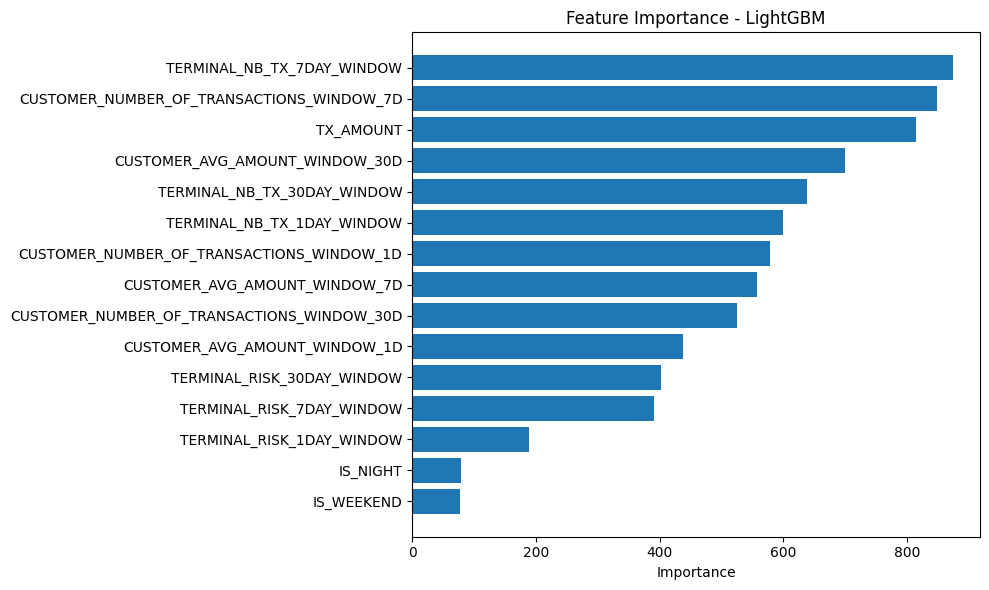

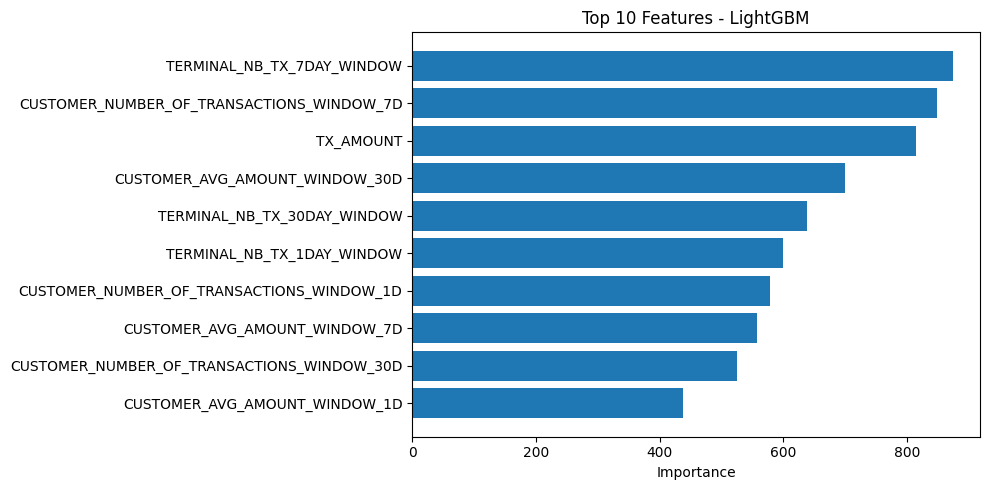

In [16]:
# FEATURE IMPORTANCE ANALYSIS
import matplotlib.pyplot as plt

print(f"\n{'#'*60}")
print("FEATURE IMPORTANCE ANALYSIS")
print(f"{'#'*60}\n")

# Get best model
best_pipeline = best_models[best_model_name]
best_model_obj = best_pipeline.named_steps['model']

# Extract feature importances
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model_obj.feature_importances_
}).sort_values('importance', ascending=False)

print(f"Top 10 Most Important Features for {best_model_name}:")
print(feature_importance.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Importance')
plt.title(f'Feature Importance - {best_model_name}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Top 10 features
plt.figure(figsize=(10, 5))
top_10 = feature_importance.head(10)
plt.barh(range(len(top_10)), top_10['importance'])
plt.yticks(range(len(top_10)), top_10['feature'])
plt.xlabel('Importance')
plt.title(f'Top 10 Features - {best_model_name}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [17]:
# SAVE BEST MODEL
import os
from datetime import datetime

import joblib
import mlflow.sklearn

print(f"\n{'#'*60}")
print("SAVING BEST MODEL")
print(f"{'#'*60}\n")

# Create models directory
os.makedirs('../models', exist_ok=True)

# Timestamp for filename
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save best model pipeline
model_filename = f'../models/fraud_detection_{best_model_name.lower()}_{timestamp}.pkl'
joblib.dump(best_pipeline, model_filename)

with mlflow.start_run(run_name="save-best-model"):
    mlflow.log_param('best_model_name', best_model_name)
    mlflow.log_metric('best_test_pr_auc', final_test_results[best_model_name]['test_pr_auc'])
    mlflow.log_metric('best_test_roc_auc', final_test_results[best_model_name]['test_roc_auc'])
    mlflow.log_metric('best_test_precision_top100', final_test_results[best_model_name]['test_precision_top100'])
    mlflow.log_artifact(model_filename)
    mlflow.sklearn.log_model(best_pipeline, artifact_path='model')

print(f"Model saved: {model_filename}")
print("\nTo load model:")
print(f"  model = joblib.load('{model_filename}')")



############################################################
SAVING BEST MODEL
############################################################



2026/06/13 13:43:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 13:43:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 13:43:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run save-best-model at: http://localhost:5000/#/experiments/3/runs/3bc9c5fcc53947cdb17cf38f1116f95d
🧪 View experiment at: http://localhost:5000/#/experiments/3
Model saved: ../models/fraud_detection_lightgbm_20260613_134331.pkl

To load model:
  model = joblib.load('../models/fraud_detection_lightgbm_20260613_134331.pkl')
